In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sktime.split import temporal_train_test_split
from sktime.forecasting.model_selection import ForecastingGridSearchCV, SlidingWindowSplitter
from sktime.forecasting.arima import ARIMA
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error

In [2]:
df = pd.read_csv('AirtrafficA4.csv')
df

,AIRLINE,YEAR,MONTH,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
0,A007,2023,JAN,"47,977","83,764","41,827","68,47,384","78,32,254","16,881.70","2,043.5"
1,A007,2023,FEB,"44,905","77,936","39,121","67,41,948","73,36,614","17,439.30","2,086.7"
2,A007,2023,MAR,"50,389","87,296","43,793","73,17,288","82,15,681","20,208.40","2,310.1"
3,A007,2023,APR,"48,752","84,232","42,615","74,06,440","80,05,648","19,432.80","2,102.9"
4,A007,2023,MAY,"50,956","87,917","44,505","81,09,626","83,75,201","24,165.10","2,102.4"
...,...,...,...,...,...,...,...,...,...,...
123,A007,2013,AUG,"12,278","21,571","11,884","15,31,406","21,39,007","9,600.00",0
124,A007,2013,SEP,"12,185","21,281","11,749","13,78,691","21,14,792","8,492.00",0
125,A007,2013,OCT,"12,780","22,345","12,296","15,10,184","22,13,139","9,111.00",0
126,A007,2013,NOV,"12,357","21,837","11,904","14,67,763","21,42,765","7,185.00",0


In [3]:
df.index = pd.PeriodIndex(pd.to_datetime(df['YEAR'].astype(str) + '-' + df['MONTH'].str.upper().str[:3], format='%Y-%b'), freq='M')

In [4]:
df = df.drop(columns=['YEAR', 'MONTH', 'AIRLINE'])
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2023-01,"47,977","83,764","41,827","68,47,384","78,32,254","16,881.70","2,043.5"
2023-02,"44,905","77,936","39,121","67,41,948","73,36,614","17,439.30","2,086.7"
2023-03,"50,389","87,296","43,793","73,17,288","82,15,681","20,208.40","2,310.1"
2023-04,"48,752","84,232","42,615","74,06,440","80,05,648","19,432.80","2,102.9"
2023-05,"50,956","87,917","44,505","81,09,626","83,75,201","24,165.10","2,102.4"
...,...,...,...,...,...,...,...
2013-08,"12,278","21,571","11,884","15,31,406","21,39,007","9,600.00",0
2013-09,"12,185","21,281","11,749","13,78,691","21,14,792","8,492.00",0
2013-10,"12,780","22,345","12,296","15,10,184","22,13,139","9,111.00",0
2013-11,"12,357","21,837","11,904","14,67,763","21,42,765","7,185.00",0


In [5]:
df = df.apply(lambda col: col.str.replace(',', '').astype(float))
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2023-01,47977.0,83764.0,41827.0,6847384.0,7832254.0,16881.7,2043.5
2023-02,44905.0,77936.0,39121.0,6741948.0,7336614.0,17439.3,2086.7
2023-03,50389.0,87296.0,43793.0,7317288.0,8215681.0,20208.4,2310.1
2023-04,48752.0,84232.0,42615.0,7406440.0,8005648.0,19432.8,2102.9
2023-05,50956.0,87917.0,44505.0,8109626.0,8375201.0,24165.1,2102.4
...,...,...,...,...,...,...,...
2013-08,12278.0,21571.0,11884.0,1531406.0,2139007.0,9600.0,0.0
2013-09,12185.0,21281.0,11749.0,1378691.0,2114792.0,8492.0,0.0
2013-10,12780.0,22345.0,12296.0,1510184.0,2213139.0,9111.0,0.0
2013-11,12357.0,21837.0,11904.0,1467763.0,2142765.0,7185.0,0.0


In [6]:
df[df.isna().any(axis=1)]

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2020-03,32233.0,56567.0,28386.0,3793464.0,4985152.0,15280.6,NaN
2020-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df = df.interpolate(method='time')

In [8]:
df = df.sort_index()

In [9]:
df

,TOTAL DEPARTURES,HOURS FLOWN,KILOMETRE FLOWN,PASSENGERS CARRIED,AVAILABLE SEAT KILOMETRE (IN THOUSAND),FREIGHT CARRIED (IN TONNE),MAIL CARRIED (IN TONNE)
2013-01,10552.0,18655.0,10112.0,1408012.0,1820105.0,6465.0,0.0
2013-02,9873.0,17374.0,9439.0,1341210.0,1698930.0,6235.0,0.0
2013-03,11393.0,20093.0,11028.0,1423569.0,1984886.0,6505.0,0.0
2013-04,11426.0,20084.0,11090.0,1511094.0,1996084.0,5903.0,0.0
2013-05,11885.0,20779.0,11533.0,1685168.0,2075882.0,7345.0,0.0
...,...,...,...,...,...,...,...
2023-04,48752.0,84232.0,42615.0,7406440.0,8005648.0,19432.8,2102.9
2023-05,50956.0,87917.0,44505.0,8109626.0,8375201.0,24165.1,2102.4
2023-06,49989.0,86217.0,43739.0,7893296.0,8254272.0,23522.6,2383.0
2023-07,52127.0,90528.0,45404.0,7674890.0,8577184.0,24885.8,2585.0


Text(0, 0.5, 'Passengers')

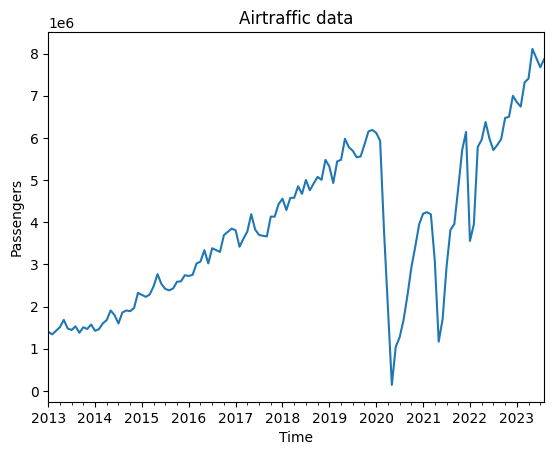

In [10]:
df['PASSENGERS CARRIED'].plot(title='Airtraffic data')
plt.xlabel('Time')
plt.ylabel('Passengers')

In [27]:
df.to_csv('AirtrafficA4_cleaned.csv')

In [11]:
X = df.drop(columns='PASSENGERS CARRIED')
y = df['PASSENGERS CARRIED']

<Axes: title={'center': 'Fourth order differencing'}>

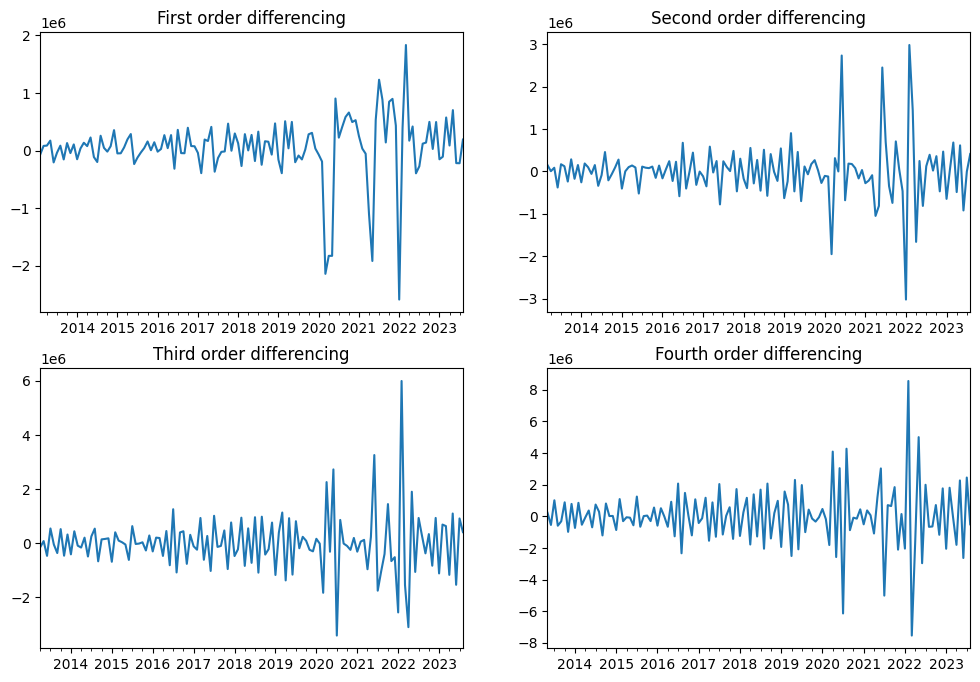

In [12]:
first_diff = y.diff().dropna()
second_diff = first_diff.diff().dropna()
third_diff = second_diff.diff().dropna()
fourth_diff = third_diff.diff().dropna()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
first_diff.plot(ax=ax[0, 0], title='First order differencing')
second_diff.plot(ax=ax[0, 1], title='Second order differencing')
third_diff.plot(ax=ax[1, 0], title='Third order differencing')
fourth_diff.plot(ax=ax[1, 1], title='Fourth order differencing')

Text(0.5, 1.0, 'PACF')

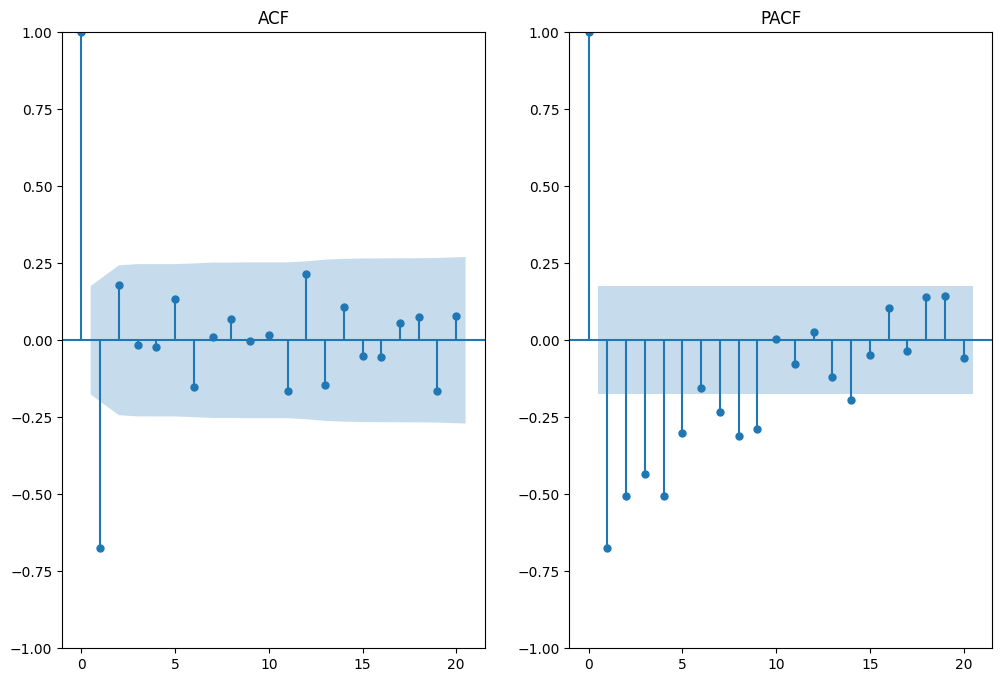

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
plot_acf(fourth_diff, lags=20, ax=ax[0])
plot_pacf(fourth_diff, lags=20, ax=ax[1])
ax[0].set_title('ACF')
ax[1].set_title('PACF')

In [14]:
y_train, y_test = temporal_train_test_split(y, test_size=20)

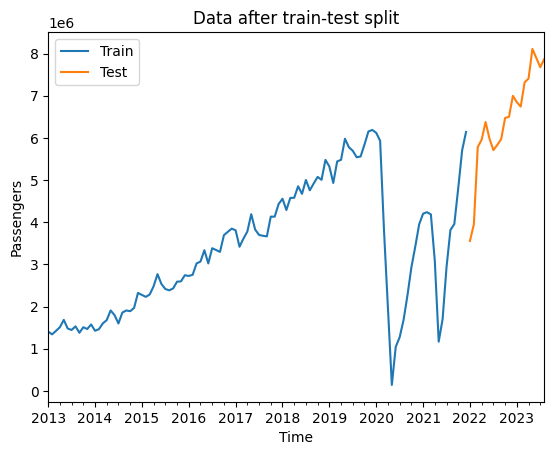

In [15]:
fig, ax = plt.subplots()
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
plt.title('Data after train-test split')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()

In [16]:
param_grid = {
    'order': [(p, d, q) for p in [1, 2] for d in [1] for q in [1, 2]],
    'seasonal_order': [(0, 0, 0, sp) for sp in [1, 4, 12]],
}
fh = np.arange(1, 1 + y_test.shape[0])
cv = SlidingWindowSplitter(window_length=60, fh=fh, step_length=36)  # Adjust parameters accordingly
forecaster = ARIMA()
gscv = ForecastingGridSearchCV(
    forecaster=forecaster,
    param_grid=param_grid,
    cv=cv,
    scoring=mean_absolute_percentage_error
)

In [17]:
gscv.fit(y_train)

ForecastingGridSearchCV(cv=SlidingWindowSplitter(fh=array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20]),
                                                 step_length=36,
                                                 window_length=60),
                        forecaster=ARIMA(),
                        param_grid={'order': [(1, 1, 1), (1, 1, 2), (2, 1, 1),
                                              (2, 1, 2)],
                                    'seasonal_order': [(0, 0, 0, 1),
                                                       (0, 0, 0, 4),
                                                       (0, 0, 0, 12)]},
                        scoring=<function mean_absolute_percentage_error at 0x000001EAE46B5BC0>)

In [18]:
gscv.best_params_

{'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 1)}

In [19]:
y_pred = gscv.predict(fh)

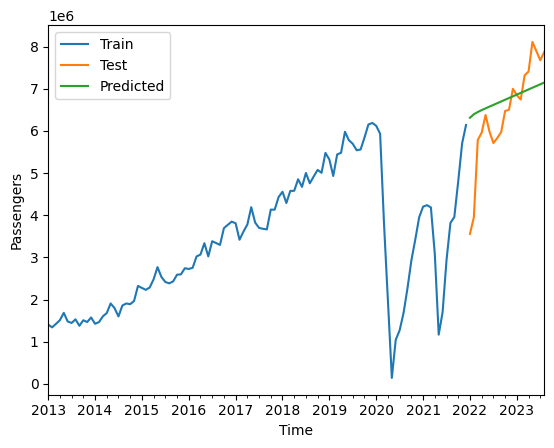

In [20]:
fig, ax = plt.subplots()
y_train.plot(ax=ax, label='Train')
y_test.plot(ax=ax, label='Test')
y_pred.plot(ax=ax, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()

In [21]:
final_model = ARIMA(order=gscv.best_params_['order'])

In [22]:
final_model.fit(y)
fh = np.arange(1, 13)  # Forecasting horizon for 12 steps ahead
y_pred = final_model.predict(fh)

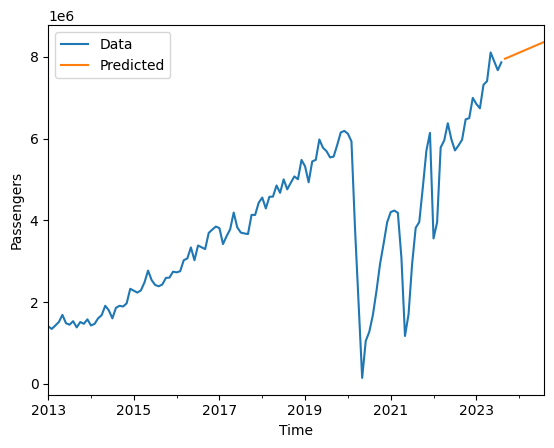

In [23]:
fig, ax = plt.subplots()
y.plot(ax=ax, label='Data')
y_pred.plot(ax=ax, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Passengers')
plt.legend()

In [24]:
# df_pred = pd.DataFrame(y_pred)
# df_pred.index = df_pred.index.to_timestamp().strftime('%Y %b').str.upper()
# df_pred = df_pred.rename_axis('YEAR_MONTH')
# df_pred.to_csv('predictions.csv')